<a href="https://colab.research.google.com/github/Mario-Cattaneo/SemesterProject/blob/main/QMIB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Collaborative DAG Pruning via Erasure-MIB
## Proof of Concept: Topology A (Asymmetric Diamond) on Split MNIST
* **Device 1 (Left View):** Fast Link ($C_1 = 50\text{ Mbps}$)
* **Device 2 (Right View):** Slow Link ($C_2 = 250\text{ kbps}$ — Bottleneck Link)
* **Device 3 (Terminal Sink):** Aggregates representations and outputs 10-class prediction.

In [1]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms

# Set device and reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
print(f"Executing on device: {device}")

Executing on device: cuda


In [2]:
class SplitMNISTDataset(Dataset):
    """
    Partitions 28x28 MNIST into two views:
    - View 1 (Device 1): Left half (28x14)
    - View 2 (Device 2): Right half (28x14)
    """
    def __init__(self, train=True):
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
        self.mnist = torchvision.datasets.MNIST(
            root='./data', train=train, download=True, transform=transform
        )

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        img, label = self.mnist[idx]
        # img shape: (1, 28, 28)
        view_1 = img[:, :, :14]   # Left half (1, 28, 14)
        view_2 = img[:, :, 14:]   # Right half (1, 28, 14)
        return view_1, view_2, label

# Instantiate loaders
train_dataset = SplitMNISTDataset(train=True)
test_dataset = SplitMNISTDataset(train=False)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, pin_memory=True)
print(f"Loaded {len(train_dataset)} training samples and {len(test_dataset)} test samples.")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.90MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]

Loaded 60000 training samples and 10000 test samples.


In [3]:
# Feature representation dimension per device
FEATURE_DIM = 64

class DeviceMicroSplit(nn.Module):
    """Local edge feature extractor for a single view (1x28x14)."""
    def __init__(self, out_dim=FEATURE_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2), # (32, 14, 7)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)), # (64, 1, 1)
            nn.Flatten(),
            nn.Linear(64, out_dim)
        )

    def forward(self, x):
        return self.net(x)

class TerminalSink(nn.Module):
    """Terminal sink classifier fusing representations from Device 1 & Device 2."""
    def __init__(self, in_dim=FEATURE_DIM * 2, num_classes=10):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, z1, z2):
        z_fused = torch.cat([z1, z2], dim=1)
        return self.classifier(z_fused)

# Quick initial pre-training to establish baseline model weights
dev1_model = DeviceMicroSplit().to(device)
dev2_model = DeviceMicroSplit().to(device)
sink_model = TerminalSink().to(device)

def pretrain_base_pipeline(epochs=3):
    print("Pre-training base pipeline (micro-splits + sink)...")
    optimizer = torch.optim.Adam(
        list(dev1_model.parameters()) + list(dev2_model.parameters()) + list(sink_model.parameters()),
        lr=1e-3
    )
    dev1_model.train(); dev2_model.train(); sink_model.train()

    for ep in range(epochs):
        total_loss, correct = 0, 0
        for v1, v2, y in train_loader:
            v1, v2, y = v1.to(device), v2.to(device), y.to(device)
            optimizer.zero_grad()
            z1 = dev1_model(v1)
            z2 = dev2_model(v2)
            out = sink_model(z1, z2)
            loss = F.cross_entropy(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y)
            correct += (out.argmax(dim=1) == y).sum().item()
        print(f"Epoch {ep+1}/{epochs} - Loss: {total_loss/len(train_dataset):.4f} - Acc: {correct/len(train_dataset)*100:.2f}%")

pretrain_base_pipeline(epochs=3)

# STRICT CONTRACT REQUIREMENT: Freeze all backbone neural weights!
for p in dev1_model.parameters(): p.requires_grad = False
for p in dev2_model.parameters(): p.requires_grad = False
for p in sink_model.parameters(): p.requires_grad = False
print("All backbone network weights are strictly FROZEN.")

Pre-training base pipeline (micro-splits + sink)...
Epoch 1/3 - Loss: 0.7021 - Acc: 77.47%
Epoch 2/3 - Loss: 0.2390 - Acc: 92.89%
Epoch 3/3 - Loss: 0.1700 - Acc: 94.80%
All backbone network weights are strictly FROZEN.


In [4]:
class STEQuantizer(torch.autograd.Function):
    """Uniform symmetric b-bit quantization with Straight-Through Estimator."""
    @staticmethod
    def forward(ctx, x, b):
        ctx.save_for_backward(x)
        levels = 2 ** (b - 1) - 1
        x_clamped = torch.clamp(x, -1.0, 1.0)
        return torch.round(x_clamped * levels) / levels

    @staticmethod
    def backward(ctx, grad_output):
        x, = ctx.saved_tensors
        # Zero gradients outside clipping range
        mask = (x >= -1.0) & (x <= 1.0)
        return grad_output * mask.float(), None

def quantize_bbit(x, b=8):
    return STEQuantizer.apply(x, b)

class MaskGradScale(torch.autograd.Function):
    """
    Custom autograd function applying the annealed STE floor (Equation 18)
    to prevent upstream gradient starvation.
    """
    @staticmethod
    def forward(ctx, z, m, floor):
        ctx.save_for_backward(m)
        ctx.floor = floor
        return z * m

    @staticmethod
    def backward(ctx, grad_output):
        m, = ctx.saved_tensors
        floor = ctx.floor
        # J_tilde = max(m, floor)
        grad_scaled = grad_output * torch.maximum(m, torch.tensor(floor, device=m.device))
        return grad_scaled, None, None

class QuantizedErasureChannel(nn.Module):
    """
    Differentiable Quantized Erasure Channel with:
    1. Learnable Hard Concrete retention logits (s)
    2. Learnable imputation vector (c) initialized to empirical mean
    3. Annealed Straight-Through Estimator floor
    """
    def __init__(self, dim=FEATURE_DIM, b_bits=8, gamma0=-0.1, zeta=1.1):
        super().__init__()
        self.dim = dim
        self.b_bits = b_bits
        self.gamma0 = gamma0
        self.zeta = zeta

        # Learnable parameters (S and C)
        self.s = nn.Parameter(torch.full((dim,), 2.0)) # Initialized to high retention (pi ~ 0.88)
        self.c = nn.Parameter(torch.zeros(dim))         # Imputation vector

    def init_imputation(self, loader, extractor, view_idx=0):
        """Initializes c with the offline empirical mean of activations."""
        extractor.eval()
        sum_feat = torch.zeros(self.dim, device=device)
        total = 0
        with torch.no_grad():
            for v1, v2, _ in loader:
                v = v1.to(device) if view_idx == 0 else v2.to(device)
                z = extractor(v)
                sum_feat += z.sum(dim=0)
                total += z.size(0)
                if total > 5000: break
        self.c.data.copy_(sum_feat / total)
        print(f"View {view_idx+1} imputation vector initialized to empirical mean.")

    def get_analytic_retention_prob(self, temp=1.0):
        """Returns analytic retention probability pi (Equation 9)."""
        offset = temp * math.log(-self.gamma0 / self.zeta)
        return torch.sigmoid(self.s - offset)

    def sample_hard_concrete(self, temp=1.0, deterministic=False):
        """Hard Concrete continuous pathwise relaxation."""
        if deterministic:
            pi = self.get_analytic_retention_prob(temp)
            return (pi >= 0.5).float()

        u = torch.rand_like(self.s).clamp(1e-6, 1.0 - 1e-6)
        logit_u = torch.log(u) - torch.log(1.0 - u)
        s_relaxed = torch.sigmoid((logit_u + self.s) / temp)
        s_stretched = s_relaxed * (self.zeta - self.gamma0) + self.gamma0
        return torch.clamp(s_stretched, 0.0, 1.0)

    def forward(self, z, temp=1.0, ste_floor=0.0, deterministic=False):
        # 1. Uniform symmetric b-bit quantization
        z_norm = torch.tanh(z)
        z_quant = quantize_bbit(z_norm, self.b_bits)

        # 2. Sample continuous/discrete mask
        m = self.sample_hard_concrete(temp=temp, deterministic=deterministic)

        # 3. Erasure Channel with Learnable Imputation & STE Floor
        # u = m * z_quant + (1 - m) * c
        z_retained = MaskGradScale.apply(z_quant, m, ste_floor)
        c_erased = (1.0 - m) * self.c
        return z_retained + c_erased

print("Quantized Erasure Channel module initialized.")

Quantized Erasure Channel module initialized.


In [5]:
class AsymmetricDiamondDAG(nn.Module):
    """
    Topology A: Two parallel edge devices feeding into a single Terminal Sink.
    - Branch 1: High Bandwidth (50 Mbps)
    - Branch 2: Bottleneck Bandwidth (250 kbps)
    """
    def __init__(self, b_bits=8, alpha=5.0):
        super().__init__()
        self.b_bits = b_bits
        self.alpha = alpha  # LogSumExp smoothing factor

        # Hardware computation execution times (milliseconds)
        self.tau_comp_1 = 1.0   # Device 1 inference: 1.0 ms
        self.tau_comp_2 = 1.0   # Device 2 inference: 1.0 ms
        self.tau_comp_sink = 0.5 # Sink inference: 0.5 ms

        # Link transmission capacities (bits per millisecond)
        # 50 Mbps = 50,000 bits/ms; 250 kbps = 250 bits/ms
        self.C_1 = 50000.0
        self.C_2 = 250.0

    def compute_link_latency(self, pi_1, pi_2):
        """Evaluates expected communication latency per link in milliseconds."""
        bits_1 = self.b_bits * torch.sum(pi_1)
        bits_2 = self.b_bits * torch.sum(pi_2)

        tau_comm_1 = bits_1 / self.C_1
        tau_comm_2 = bits_2 / self.C_2
        return tau_comm_1, tau_comm_2, bits_1, bits_2

    def forward_smoothed_latency(self, pi_1, pi_2):
        """Computes smoothed arrival times via LogSumExp (Equation 13)."""
        tau_comm_1, tau_comm_2, bits_1, bits_2 = self.compute_link_latency(pi_1, pi_2)

        T1_arrival = self.tau_comp_1 + tau_comm_1
        T2_arrival = self.tau_comp_2 + tau_comm_2

        # Smoothed join via LogSumExp
        # LSE(x1, x2) = 1/alpha * ln(exp(alpha*x1) + exp(alpha*x2))
        max_T = torch.maximum(T1_arrival, T2_arrival)
        join_arrival = max_T + (1.0 / self.alpha) * torch.log(
            torch.exp(self.alpha * (T1_arrival - max_T)) +
            torch.exp(self.alpha * (T2_arrival - max_T))
        )

        T_dag = join_arrival + self.tau_comp_sink
        return T_dag, (T1_arrival, T2_arrival), (bits_1, bits_2)

    def forward_deterministic_latency(self, K1, K2):
        """Physical deterministic latency based on discrete coordinate counts."""
        tau_comm_1 = (self.b_bits * K1) / self.C_1
        tau_comm_2 = (self.b_bits * K2) / self.C_2

        T1_arrival = self.tau_comp_1 + tau_comm_1
        T2_arrival = self.tau_comp_2 + tau_comm_2

        T_dag = max(T1_arrival, T2_arrival) + self.tau_comp_sink
        return T_dag, (T1_arrival, T2_arrival)

dag_scheduler = AsymmetricDiamondDAG(b_bits=8, alpha=5.0).to(device)
print("DAG Bellman engine initialized.")

DAG Bellman engine initialized.


In [6]:
class ALMOptimizer:
    """
    Augmented Lagrangian Method (ALM) manager for handling:
    min L_task(S, C) s.t. T_dag(S) <= T_target
    """
    def __init__(self, target_deadline_ms, lambda_init=0.0, rho_init=1.0, rho_max=50.0, gamma_rho=1.2):
        self.T_target = target_deadline_ms
        self.lambd = lambda_init
        self.rho = rho_init
        self.rho_max = rho_max
        self.gamma = gamma_rho

    def compute_loss(self, task_loss, T_dag_smooth):
        # Violation psi(S) = max(0, T_dag_smooth - T_target)
        psi = F.relu(T_dag_smooth - self.T_target)
        # ALM penalty objective (Equation 16)
        alm_penalty = self.lambd * psi + 0.5 * self.rho * (psi ** 2)
        total_loss = task_loss + alm_penalty
        return total_loss, psi.item()

    def update_multipliers(self, current_psi):
        """Periodic dual update step at epoch boundaries."""
        self.lambd = max(0.0, self.lambd + self.rho * current_psi)
        if current_psi > 0:
            self.rho = min(self.rho_max, self.rho * self.gamma)

In [7]:
# Initialize Channel Layers
chan1 = QuantizedErasureChannel(dim=FEATURE_DIM, b_bits=8).to(device)
chan2 = QuantizedErasureChannel(dim=FEATURE_DIM, b_bits=8).to(device)

# Initialize learned imputation vectors with empirical activation averages
chan1.init_imputation(train_loader, dev1_model, view_idx=0)
chan2.init_imputation(train_loader, dev2_model, view_idx=1)

# Target Deadline Constraint: Set to 2.5 ms (Forces aggressive pruning on the 250 kbps bottleneck)
TARGET_DEADLINE = 2.5
alm = ALMOptimizer(target_deadline_ms=TARGET_DEADLINE, lambda_init=0.0, rho_init=2.0)

# Optimizer ONLY tracks S and C (Zero backbone weights!)
optimizer = torch.optim.Adam([chan1.s, chan1.c, chan2.s, chan2.c], lr=0.05)

# Hyperparameter Annealing Schedules
TOTAL_EPOCHS = 15
TEMP_START, TEMP_END = 1.0, 0.2
STE_FLOOR_START = 0.05

history = {
    'epoch': [], 'task_loss': [], 'T_dag_smooth': [],
    'psi': [], 'lambda': [], 'pi_fast': [], 'pi_slow': []
}

print(f"\n--- Starting ALM Pruning (Target Deadline = {TARGET_DEADLINE} ms) ---")
for epoch in range(TOTAL_EPOCHS):
    # Anneal temperature and STE floor
    temp = TEMP_START * ((TEMP_END / TEMP_START) ** (epoch / TOTAL_EPOCHS))
    ste_floor = STE_FLOOR_START * max(0.0, 1.0 - (epoch / (TOTAL_EPOCHS * 0.75)))

    total_task_loss, epoch_psi = 0.0, 0.0

    for v1, v2, y in train_loader:
        v1, v2, y = v1.to(device), v2.to(device), y.to(device)
        optimizer.zero_grad()

        # 1. Forward through frozen feature extractors
        with torch.no_grad():
            z1 = dev1_model(v1)
            z2 = dev2_model(v2)

        # 2. Forward through differentiable erasure channels
        u1 = chan1(z1, temp=temp, ste_floor=ste_floor)
        u2 = chan2(z2, temp=temp, ste_floor=ste_floor)

        # 3. Task loss at terminal sink
        out = sink_model(u1, u2)
        loss_task = F.cross_entropy(out, y)

        # 4. Latency evaluation via smoothed Bellman DAG
        pi_1 = chan1.get_analytic_retention_prob(temp)
        pi_2 = chan2.get_analytic_retention_prob(temp)
        T_dag_smooth, _, _ = dag_scheduler.forward_smoothed_latency(pi_1, pi_2)

        # 5. ALM loss computation & backpropagation
        loss_total, psi_val = alm.compute_loss(loss_task, T_dag_smooth)
        loss_total.backward()
        optimizer.step()

        total_task_loss += loss_task.item()
        epoch_psi = psi_val

    # Epoch-level dual variable update
    alm.update_multipliers(epoch_psi)

    # Track statistics
    avg_pi_1 = chan1.get_analytic_retention_prob(temp).mean().item()
    avg_pi_2 = chan2.get_analytic_retention_prob(temp).mean().item()

    history['epoch'].append(epoch + 1)
    history['task_loss'].append(total_task_loss / len(train_loader))
    history['T_dag_smooth'].append(T_dag_smooth.item())
    history['psi'].append(epoch_psi)
    history['lambda'].append(alm.lambd)
    history['pi_fast'].append(avg_pi_1)
    history['pi_slow'].append(avg_pi_2)

    print(f"Epoch {epoch+1:02d} | T_DAG: {T_dag_smooth.item():.2f}ms (Tgt: {TARGET_DEADLINE}ms) | "
          f"Violation: {epoch_psi:.3f} | Retain Fast: {avg_pi_1*100:.1f}% | Retain Slow: {avg_pi_2*100:.1f}%")

View 1 imputation vector initialized to empirical mean.
View 2 imputation vector initialized to empirical mean.

--- Starting ALM Pruning (Target Deadline = 2.5 ms) ---
Epoch 01 | T_DAG: 2.39ms (Tgt: 2.5ms) | Violation: 0.000 | Retain Fast: 97.1% | Retain Slow: 43.3%
Epoch 02 | T_DAG: 2.30ms (Tgt: 2.5ms) | Violation: 0.000 | Retain Fast: 94.1% | Retain Slow: 38.9%
Epoch 03 | T_DAG: 2.27ms (Tgt: 2.5ms) | Violation: 0.000 | Retain Fast: 92.1% | Retain Slow: 37.2%
Epoch 04 | T_DAG: 2.23ms (Tgt: 2.5ms) | Violation: 0.000 | Retain Fast: 90.5% | Retain Slow: 35.3%
Epoch 05 | T_DAG: 2.26ms (Tgt: 2.5ms) | Violation: 0.000 | Retain Fast: 89.9% | Retain Slow: 36.7%
Epoch 06 | T_DAG: 2.30ms (Tgt: 2.5ms) | Violation: 0.000 | Retain Fast: 89.4% | Retain Slow: 39.1%
Epoch 07 | T_DAG: 2.34ms (Tgt: 2.5ms) | Violation: 0.000 | Retain Fast: 90.3% | Retain Slow: 40.7%
Epoch 08 | T_DAG: 2.37ms (Tgt: 2.5ms) | Violation: 0.000 | Retain Fast: 90.2% | Retain Slow: 42.3%
Epoch 09 | T_DAG: 2.39ms (Tgt: 2.5ms) |

In [8]:
def extract_contract(channel, temp=0.2):
    """Offline topological contract extraction: Omega = {k | pi_k >= 0.5}."""
    with torch.no_grad():
        pi = channel.get_analytic_retention_prob(temp=temp)
        Omega = (pi >= 0.5).nonzero(as_tuple=True)[0].cpu().numpy()
        c_vector = channel.c.clone().detach()
    return Omega, c_vector

Omega_1, c1_fixed = extract_contract(chan1)
Omega_2, c2_fixed = extract_contract(chan2)

print("\n================ DEPLOYED STATIC TOPOLOGICAL CONTRACT ================")
print(f"Link 1 (Fast Link - 50 Mbps)  : Retained {len(Omega_1)}/{FEATURE_DIM} channels ({len(Omega_1)/FEATURE_DIM*100:.1f}%)")
print(f"Link 2 (Slow Link - 250 kbps) : Retained {len(Omega_2)}/{FEATURE_DIM} channels ({len(Omega_2)/FEATURE_DIM*100:.1f}%)")

# Evaluate True Physical Performance under Deployment Contract
sink_model.eval()
correct, total = 0, 0

with torch.no_grad():
    for v1, v2, y in test_loader:
        v1, v2, y = v1.to(device), v2.to(device), y.to(device)

        # 1. Edge extraction
        z1 = dev1_model(v1)
        z2 = dev2_model(v2)

        # 2. Zero-Overhead Hardware Emulation:
        # Transmitter only transmits coordinates in Omega
        z1_tx = z1[:, Omega_1]
        z2_tx = z2[:, Omega_2]

        # Receiver unpacks and imputes with c
        u1_rx = torch.tile(c1_fixed, (z1.size(0), 1))
        u2_rx = torch.tile(c2_fixed, (z2.size(0), 1))

        u1_rx[:, Omega_1] = quantize_bbit(torch.tanh(z1_tx), b=8)
        u2_rx[:, Omega_2] = quantize_bbit(torch.tanh(z2_tx), b=8)

        # 3. Sink Inference
        out = sink_model(u1_rx, u2_rx)
        correct += (out.argmax(dim=1) == y).sum().item()
        total += len(y)

deployed_acc = correct / total * 100
T_deterministic, (t1, t2) = dag_scheduler.forward_deterministic_latency(len(Omega_1), len(Omega_2))

print(f"\nFinal Test Accuracy: {deployed_acc:.2f}%")
print(f"True Deployed Latency: {T_deterministic:.2f} ms (Target Deadline: {TARGET_DEADLINE} ms)")
print(f"  Branch 1 Finish Time: {t1:.2f} ms")
print(f"  Branch 2 Finish Time: {t2:.2f} ms (Bottleneck)")
print(f"Deadline Satisfied? {'YES (Compliant)' if T_deterministic <= TARGET_DEADLINE else 'NO (Violated)'}")
print("=======================================================================")


================ DEPLOYED STATIC TOPOLOGICAL CONTRACT ================
Link 1 (Fast Link - 50 Mbps)  : Retained 59/64 channels (92.2%)
Link 2 (Slow Link - 250 kbps) : Retained 29/64 channels (45.3%)

Final Test Accuracy: 94.35%
True Deployed Latency: 2.43 ms (Target Deadline: 2.5 ms)
  Branch 1 Finish Time: 1.01 ms
  Branch 2 Finish Time: 1.93 ms (Bottleneck)
Deadline Satisfied? YES (Compliant)


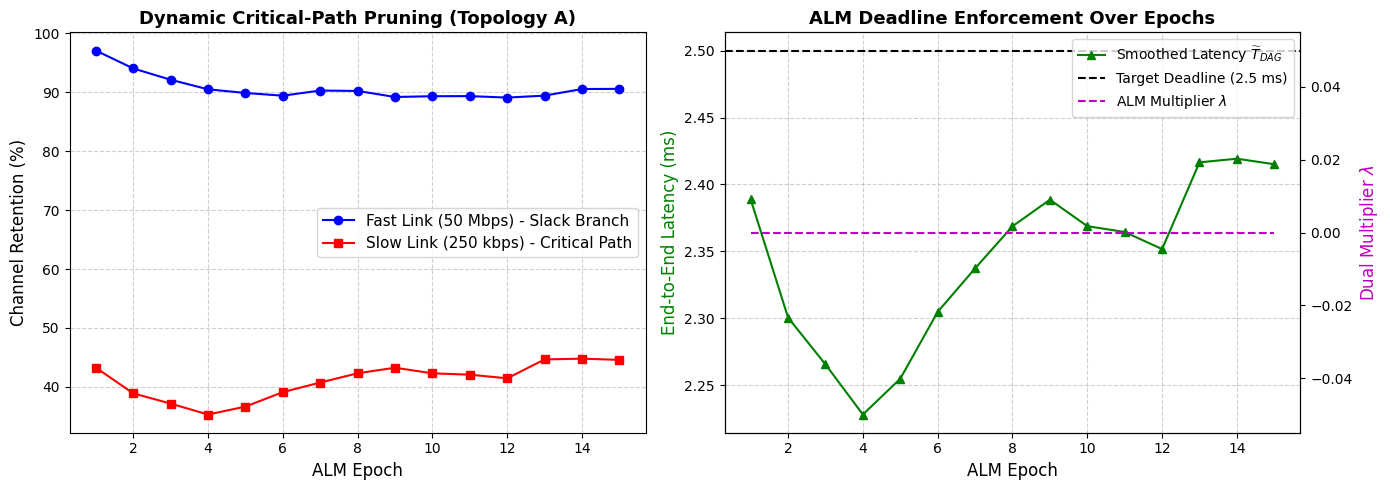

In [9]:
# Generate presentation figures: Dynamic Asymmetric Routing and ALM Convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Asymmetric Critical-Path Pruning
axes[0].plot(history['epoch'], [p*100 for p in history['pi_fast']], 'b-o', label='Fast Link (50 Mbps) - Slack Branch')
axes[0].plot(history['epoch'], [p*100 for p in history['pi_slow']], 'r-s', label='Slow Link (250 kbps) - Critical Path')
axes[0].set_xlabel('ALM Epoch', fontsize=12)
axes[0].set_ylabel('Channel Retention (%)', fontsize=12)
axes[0].set_title('Dynamic Critical-Path Pruning (Topology A)', fontsize=13, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=11)

# Plot 2: Deadline Compliance & Dual Variable Convergence
ax2_twin = axes[1].twinx()
p1 = axes[1].plot(history['epoch'], history['T_dag_smooth'], 'g-^', label='Smoothed Latency $\\widetilde{T}_{DAG}$')
p2 = axes[1].axhline(y=TARGET_DEADLINE, color='k', linestyle='--', label=f'Target Deadline ({TARGET_DEADLINE} ms)')
p3 = ax2_twin.plot(history['epoch'], history['lambda'], 'm--', label='ALM Multiplier $\\lambda$')

axes[1].set_xlabel('ALM Epoch', fontsize=12)
axes[1].set_ylabel('End-to-End Latency (ms)', color='g', fontsize=12)
ax2_twin.set_ylabel('Dual Multiplier $\\lambda$', color='m', fontsize=12)
axes[1].set_title('ALM Deadline Enforcement Over Epochs', fontsize=13, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Combine legends for twin axis
lines = p1 + [p2] + p3
labels = [l.get_label() for l in lines]
axes[1].legend(lines, labels, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

Pre-caching intermediate features into GPU RAM...
Features cached in 17.57s! Training will now be nearly instantaneous.

=== UNCOMPRESSED BASELINE ===
Accuracy: 94.91% | Bits: 1024 | Latency: 3.55 ms

Running fast sweep across 6 target deadlines...
Full sweep completed in 135.70 seconds!



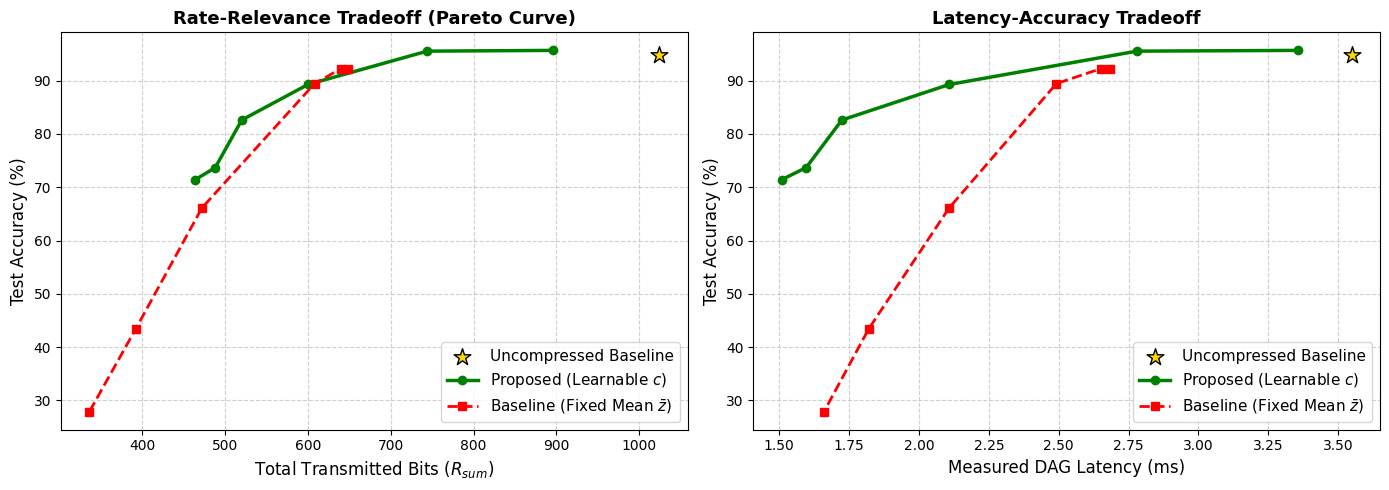

In [11]:
# ==============================================================================
# Fast Pre-Cached Multi-Deadline Sweep with Uncompressed Baseline
# ==============================================================================
import time

print("Pre-caching intermediate features into GPU RAM...")
t0 = time.time()

# 1. Pre-extract frozen features once
dev1_model.eval(); dev2_model.eval()
with torch.no_grad():
    # Cache training set
    z1_train_list, z2_train_list, y_train_list = [], [], []
    for v1, v2, y in train_loader:
        z1_train_list.append(dev1_model(v1.to(device)))
        z2_train_list.append(dev2_model(v2.to(device)))
        y_train_list.append(y.to(device))
    Z1_train = torch.cat(z1_train_list, dim=0)
    Z2_train = torch.cat(z2_train_list, dim=0)
    Y_train = torch.cat(y_train_list, dim=0)

    # Cache test set
    z1_test_list, z2_test_list, y_test_list = [], [], []
    for v1, v2, y in test_loader:
        z1_test_list.append(dev1_model(v1.to(device)))
        z2_test_list.append(dev2_model(v2.to(device)))
        y_test_list.append(y.to(device))
    Z1_test = torch.cat(z1_test_list, dim=0)
    Z2_test = torch.cat(z2_test_list, dim=0)
    Y_test = torch.cat(y_test_list, dim=0)

print(f"Features cached in {time.time() - t0:.2f}s! Training will now be nearly instantaneous.\n")

# 2. Evaluate Uncompressed Anchor Point (No Pruning)
sink_model.eval()
with torch.no_grad():
    u1_unpruned = quantize_bbit(torch.tanh(Z1_test), b=8)
    u2_unpruned = quantize_bbit(torch.tanh(Z2_test), b=8)
    out_unpruned = sink_model(u1_unpruned, u2_unpruned)
    uncompressed_acc = (out_unpruned.argmax(dim=1) == Y_test).sum().item() / len(Y_test) * 100.0

uncompressed_bits = 8 * (FEATURE_DIM + FEATURE_DIM) # 1024 bits
uncompressed_lat, _ = dag_scheduler.forward_deterministic_latency(FEATURE_DIM, FEATURE_DIM)

print(f"=== UNCOMPRESSED BASELINE ===")
print(f"Accuracy: {uncompressed_acc:.2f}% | Bits: {uncompressed_bits} | Latency: {uncompressed_lat:.2f} ms\n")

# 3. Fast Training Function operating strictly on cached tensors
def fast_train_target(target_deadline, use_learnable_c=True, epochs=12, batch_size=256):
    ch1 = QuantizedErasureChannel(dim=FEATURE_DIM, b_bits=8).to(device)
    ch2 = QuantizedErasureChannel(dim=FEATURE_DIM, b_bits=8).to(device)
    ch1.c.data.copy_(Z1_train.mean(dim=0))
    ch2.c.data.copy_(Z2_train.mean(dim=0))

    if not use_learnable_c:
        ch1.c.requires_grad = False
        ch2.c.requires_grad = False
        params = [ch1.s, ch2.s]
    else:
        params = [ch1.s, ch1.c, ch2.s, ch2.c]

    opt = torch.optim.Adam(params, lr=0.05)
    alm_inst = ALMOptimizer(target_deadline_ms=target_deadline, rho_init=3.0)

    num_samples = len(Y_train)
    for ep in range(epochs):
        temp = 1.0 * ((0.2 / 1.0) ** (ep / epochs))
        ste = 0.05 * max(0.0, 1.0 - (ep / (epochs * 0.75)))
        perm = torch.randperm(num_samples)

        for i in range(0, num_samples, batch_size):
            idx = perm[i:i+batch_size]
            z1_b, z2_b, y_b = Z1_train[idx], Z2_train[idx], Y_train[idx]

            opt.zero_grad()
            u1 = ch1(z1_b, temp=temp, ste_floor=ste)
            u2 = ch2(z2_b, temp=temp, ste_floor=ste)
            out = sink_model(u1, u2)
            loss_task = F.cross_entropy(out, y_b)

            p1 = ch1.get_analytic_retention_prob(temp)
            p2 = ch2.get_analytic_retention_prob(temp)
            t_smooth, _, _ = dag_scheduler.forward_smoothed_latency(p1, p2)

            loss_tot, psi_val = alm_inst.compute_loss(loss_task, t_smooth)
            loss_tot.backward()
            opt.step()
        alm_inst.update_multipliers(psi_val)

    Omega1, c1_vec = extract_contract(ch1)
    Omega2, c2_vec = extract_contract(ch2)

    # Fast vectorized test evaluation
    with torch.no_grad():
        u1_rx = torch.tile(c1_vec, (len(Z1_test), 1))
        u2_rx = torch.tile(c2_vec, (len(Z2_test), 1))
        if len(Omega1) > 0:
            u1_rx[:, Omega1] = quantize_bbit(torch.tanh(Z1_test[:, Omega1]), b=8)
        if len(Omega2) > 0:
            u2_rx[:, Omega2] = quantize_bbit(torch.tanh(Z2_test[:, Omega2]), b=8)
        out_test = sink_model(u1_rx, u2_rx)
        acc = (out_test.argmax(dim=1) == Y_test).sum().item() / len(Y_test) * 100.0

    total_bits = 8 * (len(Omega1) + len(Omega2))
    t_det, _ = dag_scheduler.forward_deterministic_latency(len(Omega1), len(Omega2))
    return acc, total_bits, t_det

# 4. Sweep execution across wide deadline range
deadlines = [3.55, 3.0, 2.5, 2.1, 1.85, 1.70]
res_learnable = {'acc': [], 'bits': [], 'lat': []}
res_fixed = {'acc': [], 'bits': [], 'lat': []}

print("Running fast sweep across 6 target deadlines...")
t_sweep = time.time()
for d in deadlines:
    acc, bits, lat = fast_train_target(d, use_learnable_c=True)
    res_learnable['acc'].append(acc); res_learnable['bits'].append(bits); res_learnable['lat'].append(lat)

    acc_f, bits_f, lat_f = fast_train_target(d, use_learnable_c=False)
    res_fixed['acc'].append(acc_f); res_fixed['bits'].append(bits_f); res_fixed['lat'].append(lat_f)
print(f"Full sweep completed in {time.time() - t_sweep:.2f} seconds!\n")

# 5. Publication-Ready Plots with Uncompressed Reference
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Rate-Relevance (Accuracy vs. Bits)
ax[0].scatter([uncompressed_bits], [uncompressed_acc], color='gold', edgecolor='black', s=160, zorder=5, marker='*', label='Uncompressed Baseline')
ax[0].plot(res_learnable['bits'], res_learnable['acc'], 'g-o', linewidth=2.5, label='Proposed (Learnable $c$)')
ax[0].plot(res_fixed['bits'], res_fixed['acc'], 'r--s', linewidth=2, label='Baseline (Fixed Mean $\\bar{z}$)')
ax[0].set_xlabel('Total Transmitted Bits ($R_{sum}$)', fontsize=12)
ax[0].set_ylabel('Test Accuracy (%)', fontsize=12)
ax[0].set_title('Rate-Relevance Tradeoff (Pareto Curve)', fontsize=13, fontweight='bold')
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].legend(fontsize=11, loc='lower right')

# Plot 2: Latency-Accuracy Tradeoff
ax[1].scatter([uncompressed_lat], [uncompressed_acc], color='gold', edgecolor='black', s=160, zorder=5, marker='*', label='Uncompressed Baseline')
ax[1].plot(res_learnable['lat'], res_learnable['acc'], 'g-o', linewidth=2.5, label='Proposed (Learnable $c$)')
ax[1].plot(res_fixed['lat'], res_fixed['acc'], 'r--s', linewidth=2, label='Baseline (Fixed Mean $\\bar{z}$)')
ax[1].set_xlabel('Measured DAG Latency (ms)', fontsize=12)
ax[1].set_ylabel('Test Accuracy (%)', fontsize=12)
ax[1].set_title('Latency-Accuracy Tradeoff', fontsize=13, fontweight='bold')
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].legend(fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()